# General Monte Carlo algorithm for estimating the area of arbitrary 2D regions.

### 1. Introduction
This notebook applies Monte Carlo methodology to integrate function over a definite interval. The number of samples, interval range and integrand are not hard coded, feel free to change them and experiment. Plots of the simulation, computation cost and error analysis are built into the functions, with a pandas DataFrame containing key results over 100 iterations of provided sample numbers.

In [1]:
import numpy as np
from numpy import random
import pandas as pd
import matplotlib.pyplot as plt
import time

#gives exact integral values for comparison
from scipy.integrate import quad

In [2]:
#number of random samples taken per simulation
sample_number = 10000

#limits of integration
x_range = [0, 20]

#set seed for reproducability 
rng = np.random.default_rng(10) 

### 2. Example functions
If writing your own function, ensure $y \geq 0$ over the entire integration interval, otherwise unexpected behaviour will result!

In [3]:
def polynomial(x):
    return 2 - x + 0.2 * x**2

def exponential(x):
    return np.exp(-x)

def normal_dist(x):
    return np.e**(x**2 / -2) / (np.sqrt(2 * np.pi))

def mixed_function(x):
    return np.sin(x) + 0.05 * x**2

### 3. Simulation

In [9]:
# Find maximum y value in the range
def y_max_calc(x_range, integrand):
    x_values = np.linspace(x_range[0], x_range[1], 10000)
    y_values = integrand(x_values)
    y_max = np.max(y_values)

    headroom = 1.1
    y_max *= headroom 
    return y_max

def monteCarloSim(sample_number, x_range, y_max, integrand, plot=True):  

    """
    Estimate a definite integral using Monte Carlo integration.

    Random points are uniformly sampled within a rectangular region
    containing the area under the integrand. The proportion of points
    falling below the curve is used to estimate the integral.
    
    """
    # Generate all random samples at once
    x_samples = rng.uniform(x_range[0], x_range[1], sample_number)
    y_samples = rng.uniform(0, y_max, sample_number)

    # Determine which points lie below the curve
    inside = y_samples <= integrand(x_samples)

    # Estimate integral
    area = y_max * abs(x_range[1] - x_range[0])
    integral = area * np.mean(inside)

    if plot:
        colours = np.where(inside, "blue", "red")

        fig, ax = plt.subplots(figsize=(8, 8))

        ax.scatter(
            x_samples,
            y_samples,
            s=2,
            color=colours,
            alpha=0.4
        )

        ax.set_title("Monte Carlo Simulation")
        ax.set_xlabel("x axis")
        ax.set_ylabel("y axis")

        plt.show()

    return integral

In [10]:
def error_calc (sample_number, x_range, integrand, info=False, plot=False):

    
    I, quad_error = quad(integrand, x_range[0], x_range[1])
    
    I_est = monteCarloSim(
        sample_number, 
        x_range, 
        y_max, 
        integrand, 
        plot=plot
    )
    
    error = abs(I - I_est)

    if info:
        print(f"To 2dp, the integral result to 2dp is: {I:.2f}")
        print(f"The Monte Carlo method using {sample_number} samples obtained a value of: {I_est:.2f}")
        print(f"The error on this result is {error:.2f}. As a percentage: {100*error/I:.2f}%")
        return
        
    return error

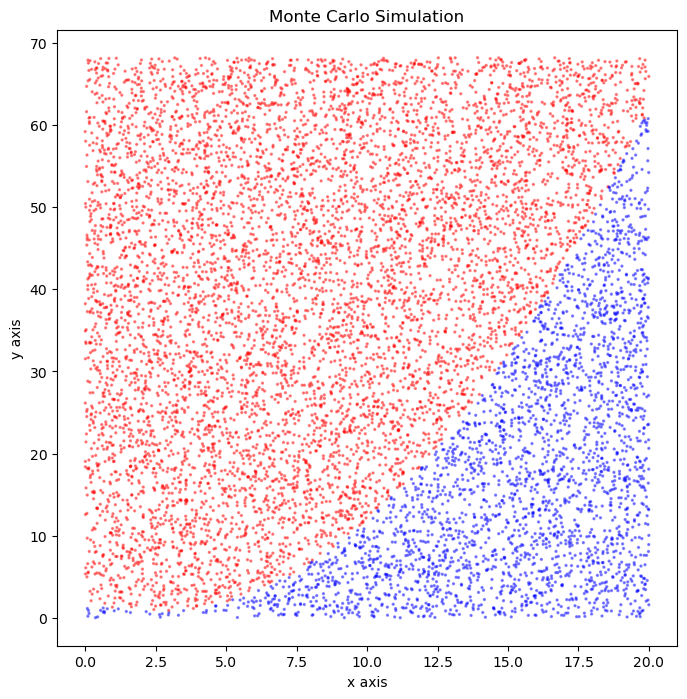

To 2dp, the integral result to 2dp is: 373.33
The Monte Carlo method using 10000 samples obtained a value of: 376.33
The error on this result is 2.99. As a percentage: 0.80%


In [11]:
#run and display a single simulation
y_max = y_max_calc(x_range, polynomial)
error_calc(sample_number, x_range, polynomial, info=True, plot=True)

### 4. Error and Runtime Analysis

In [12]:
def error_sample_analysis(sample_numbers, x_range, integrand):

    """
    Analyse Monte Carlo integration accuracy and computational cost
    for different numbers of random samples.

    For each sample size, the Monte Carlo simulation is repeated 100
    times. The mean absolute error and standard deviation of the
    estimates are calculated relative to a reference integral obtained
    using SciPy's numerical integration. The total runtime of the 100
    simulations is also recorded.

    A log-log linear fit is performed on the mean absolute error against
    the number of samples to estimate the empirical convergence rate.
    The local runtime scaling between consecutive sample sizes is also
    calculated.
    """
    mean_errors = []
    std_errors = []
    percent_errors = []
    times = []

    # Calculate exact integral once
    true_integral, quad_error = quad(
        integrand,
        x_range[0],
        x_range[1]
    )

    # Calculate y_max once
    y_max = y_max_calc(x_range, integrand)

    #iterate over number of samples
    for sample in sample_numbers:

        errors = []

        #to measure runtime of monteCarloSim()
        start_time = time.perf_counter()

        #take mean of 100 results for accuracy (Central Limit Theorem)
        for _ in range(100):

            estimate = monteCarloSim(
                sample,
                x_range,
                y_max,
                integrand,
                plot=False
            )

            errors.append(
                abs(true_integral - estimate)
            )

        end_time = time.perf_counter()

        times.append(end_time - start_time)

        mean_errors.append(np.mean(errors))
        std_errors.append(np.std(errors))
        percent_errors.append(100*np.mean(errors)/true_integral)

    # Calculate error convergence gradient
    log_samples = np.log(sample_numbers)
    log_errors = np.log(mean_errors)

    gradient, intercept = np.polyfit(
        log_samples,
        log_errors,
        1
    )
    
    #runtime - error analysis
    scaling_val = ['-']
    for i in range(len(sample_numbers) - 1):
        runtime_ratio = times[i+1] / times[i]
        sample_ratio = sample_numbers[i+1] / sample_numbers[i]    
        multiplier = np.log(runtime_ratio) / np.log(sample_ratio)
        scaling_val.append(multiplier)
    # Plot
    fig, ax = plt.subplots(2)

    fig.suptitle("Accuracy to runtime comparison")

    ax[0].errorbar(
        sample_numbers,
        mean_errors,
        yerr=std_errors,
        fmt='o-',
        label=f"Gradient = {gradient:.3f}"
    )

    ax[1].plot(
        sample_numbers,
        times,
        'o-'
    )

    ax[0].set_xlabel("Number of samples")
    ax[0].set_ylabel("Mean absolute error")

    ax[1].set_xlabel("Number of samples")
    ax[1].set_ylabel("Runtime for 500 simulations (s)")

    ax[0].set_xscale("log")
    ax[0].set_yscale("log")

    ax[1].set_xscale("log")
    ax[1].set_yscale("log")

    ax[0].legend()

    plt.show()

    # display DataFrame
    results_df = pd.DataFrame({"samples": sample_numbers, 
                              "Mean Error": mean_errors,
                               "Mean Percentage Error": percent_errors,
                               "Standard Deviation": std_errors,
                              "Runtime (s)": times,
                              "Runtime Scaling": scaling_val}
                             )
    results_df = results_df.set_index("samples")
    display(results_df)
    
    return

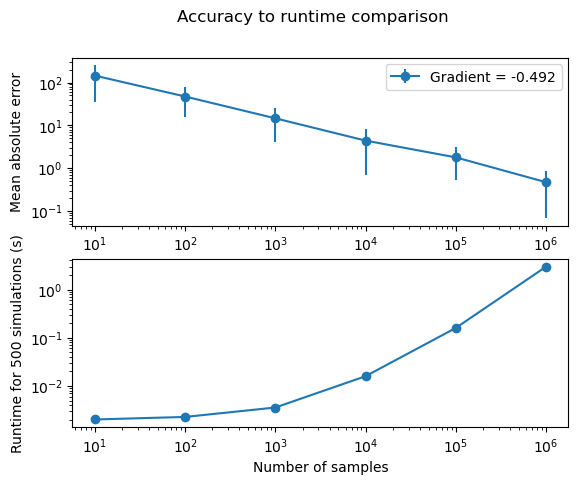

,Mean Error,Mean Percentage Error,Standard Deviation,Runtime (s),Runtime Scaling
samples,,,,,
10,144.948000,38.825357,109.539729,0.002023,-
100,47.128667,12.623750,31.099678,0.002286,0.052971
1000,14.603507,3.911654,10.425860,0.003584,0.195317
10000,4.410204,1.181305,3.729735,0.015964,0.648772
100000,1.791733,0.479929,1.263513,0.159466,0.999535
1000000,0.472092,0.126453,0.402899,2.963325,1.269112


In [13]:
sample_numbers = [10, 100, 1000, 10000, 100000, 1000000]
error_sample_analysis(sample_numbers, x_range, polynomial)